In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler, PowerTransformer, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator

from sklearn.model_selection import train_test_split

import  data_clean_utils

In [2]:
# isse output numpy array ki jgh dataframe me ata hai jisse se columns name presrve rhtra hai 
from sklearn import set_config
set_config(transform_output='pandas')

## Load the data

In [3]:
df = pd.read_csv('train.csv')

## Clean data

In [4]:
data_clean_utils.perform_data_cleanining(df)

In [5]:
df = pd.read_csv('cleaned-data.csv')

In [6]:
df

,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


In [7]:
df.columns

Index(['rider_id', 'rider_age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [8]:
cols_to_drop = ['rider_id', 'restaurant_latitude',
                'restaurant_longitude', 'delivery_latitude',
                'order_date', 'delivery_longitude',
                'order_day','order_time_hour']

df.drop(columns=cols_to_drop, inplace=True)
df

,rider_age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,3,saturday,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,3,friday,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,3,saturday,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,4,tuesday,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,3,saturday,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,JAP,3,thursday,0,10.0,morning,1.489846,short
45498,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,AGR,2,wednesday,0,15.0,evening,NaN,NaN
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,CHEN,3,friday,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,COIMB,3,monday,0,5.0,afternoon,6.232393,medium


In [9]:
df.isna().sum()

,0
rider_age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


In [10]:
df.duplicated().sum()

np.int64(0)

<Axes: >

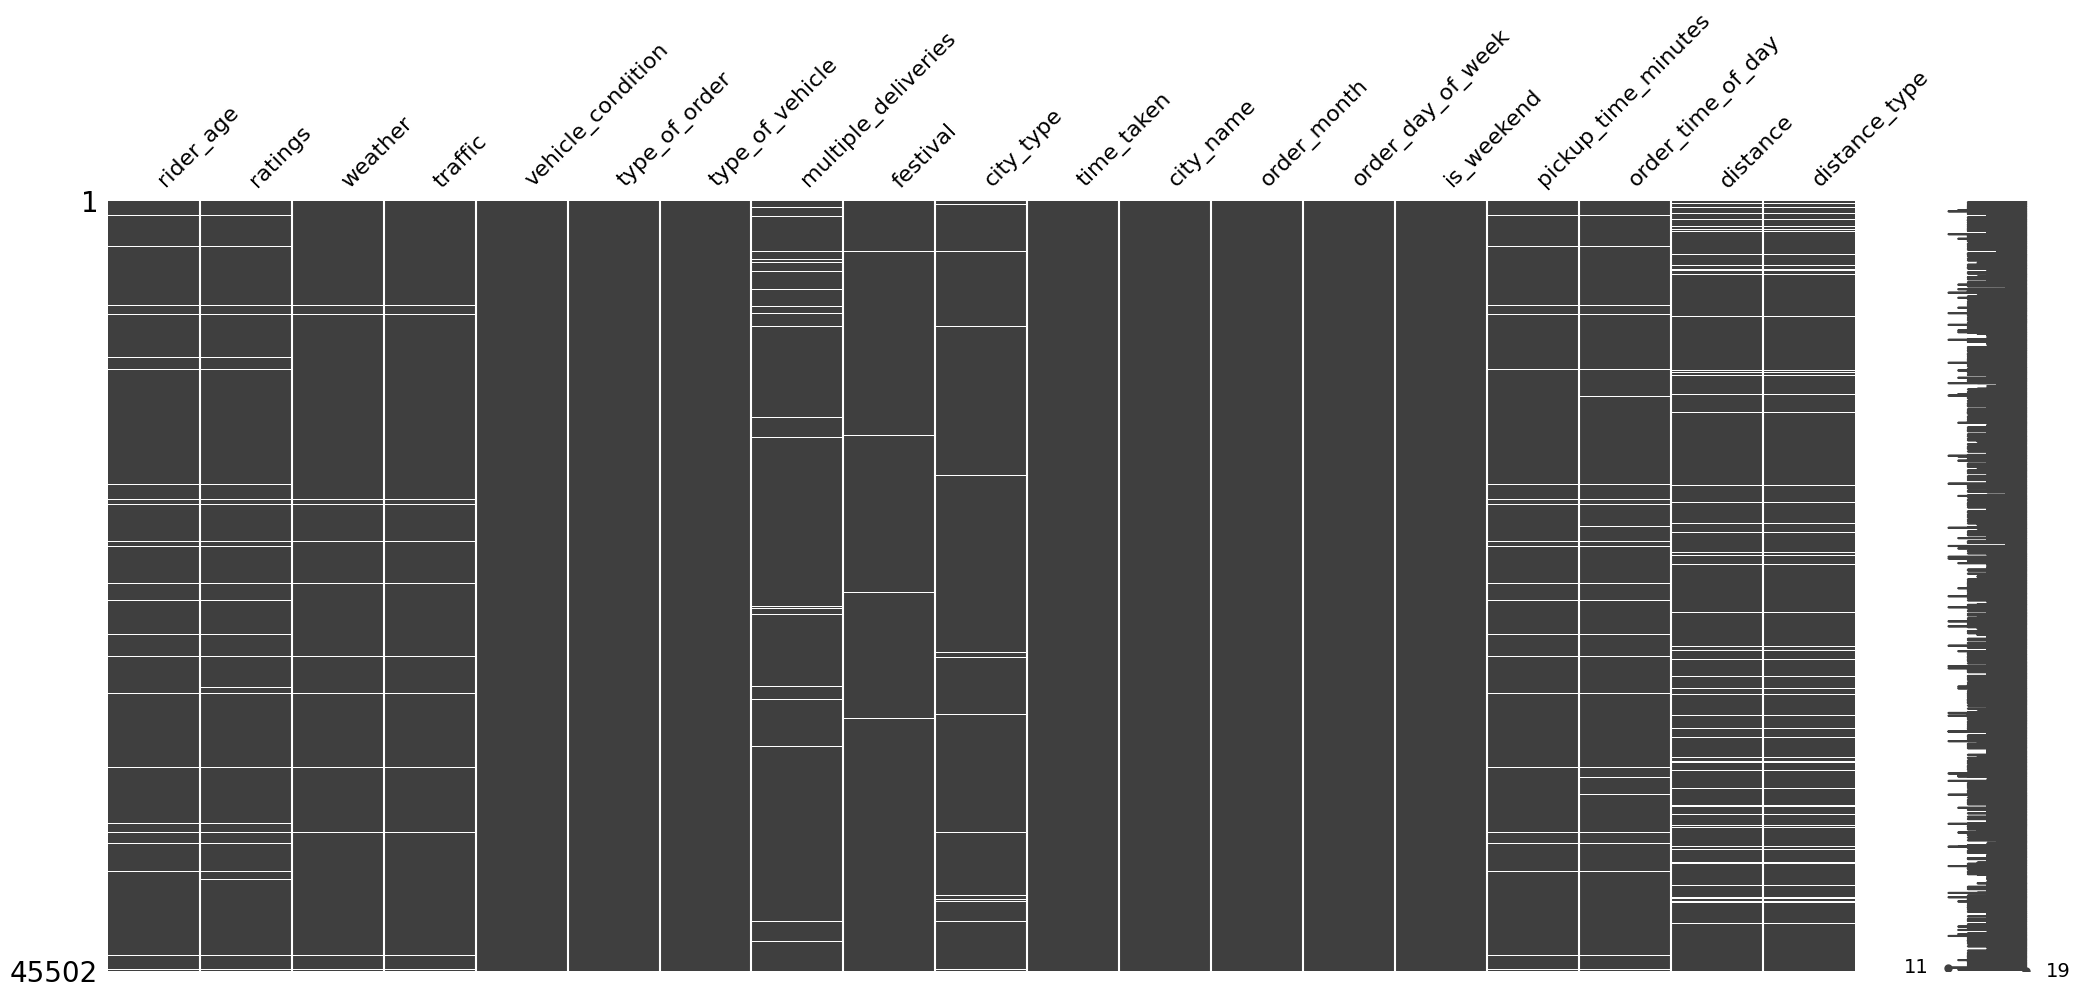

In [11]:
import missingno as msno
msno.matrix(df)

In [12]:
missing_cols = (
    df
    .isna()
    .any(axis=0)
    .loc[lambda x: x]
    .index
)

missing_cols

Index(['rider_age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

## Data prep

In [13]:
temp_df = df.copy().dropna()

In [14]:
temp_df.shape

(37695, 19)

In [15]:
x = temp_df.drop(columns=['time_taken'])
y = temp_df['time_taken']

x

,rider_age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,city_name,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,INDO,3,saturday,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,BANG,3,friday,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,BANG,3,saturday,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,COIMB,4,tuesday,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,CHEN,3,saturday,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45496,35.0,4.2,windy,jam,2,drinks,motorcycle,1.0,no,metropolitian,RANCHI,3,tuesday,0,10.0,night,16.600272,very_long
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,JAP,3,thursday,0,10.0,morning,1.489846,short
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,CHEN,3,friday,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,COIMB,3,monday,0,5.0,afternoon,6.232393,medium


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [17]:
print(f'train_data shape is {x_train.shape}')
print(f'test_data shape is {x_test.shape}')

train_data shape is (30156, 18)
test_data shape is (7539, 18)


In [18]:
x_train.isna().sum()

,0
rider_age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [19]:
x_train.columns

Index(['rider_age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'city_name', 'order_month', 'order_day_of_week',
       'is_weekend', 'pickup_time_minutes', 'order_time_of_day', 'distance',
       'distance_type'],
      dtype='object')

In [20]:
len(x_train.columns)

18

In [21]:
num_cols = ['rider_age', 'ratings', 
            'pickup_time_minutes', 'distance']

nominal_cat_cols = ['weather', 'type_of_vehicle', 'festival',
                    'city_type', 'city_name', 'order_month',
                    'order_day_of_week', 'is_weekend',
                    'order_time_of_day', 'type_of_order']

ordinal_cat_cols = ['traffic', 'distance_type']

In [22]:
len(num_cols + ordinal_cat_cols + nominal_cat_cols)

16

In [23]:
for col in ordinal_cat_cols:
    print(col, x_train[col].unique())

traffic ['jam' 'medium' 'high' 'low']
distance_type ['medium' 'short' 'long' 'very_long']


In [24]:
traffic_order = ['low', 'medium', 'high', 'jam']
distance_type_order = ['short', 'medium', 'long', 'very_long'] 

In [25]:
preprocessor = ColumnTransformer(transformers=[
    ('scale', MinMaxScaler(), num_cols),
    ('nominal_encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cat_cols),
    ('ordinal_encode', OrdinalEncoder(categories=[traffic_order, distance_type_order]), ordinal_cat_cols)
], remainder='passthrough', n_jobs=-1, force_int_remainder_cols=False, verbose_feature_names_out=False)

preprocessor.set_output(transform='pandas')

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['rider_age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_vehicle', 'festival',
                                  'city_type', 'city_name', 'order_month',
                                  'order_day_of_week', 'is_weekend',
                                  'order_time_of_day', 'type_of_order']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']]),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [26]:
x_train_trans = preprocessor.fit_transform(x_train)
x_test_trans = preprocessor.transform(x_test)

x_train_trans

,rider_age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_vehicle_motorcycle,...,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,type_of_order_drinks,type_of_order_meal,type_of_order_snack,traffic,distance_type,vehicle_condition,multiple_deliveries
8708,0.473684,0.56,1.0,0.404165,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,1.0,0,2.0
25198,1.000000,0.76,0.0,0.154044,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1.0
34049,0.473684,0.80,0.5,0.002461,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1,0.0
25987,1.000000,0.92,1.0,0.460411,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0,1.0
37121,0.526316,0.76,0.5,0.243676,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20239,0.578947,0.92,0.5,0.451895,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0,0,0.0
7590,0.052632,1.00,1.0,0.612270,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,1,1.0
13610,0.526316,0.92,0.0,0.322877,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1,0.0
1045,0.947368,0.96,0.5,0.004486,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1.0


In [27]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))


In [28]:
pt.lambdas_

array([0.32446096])

In [29]:
y_train_pt

,x0
0,2.028672
1,0.554539
2,-2.024267
3,-0.173699
4,0.554539
...,...
30151,0.457580
30152,-0.173699
30153,-1.350937
30154,0.047111


## Train baseline model

In [30]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(x_train_trans, y_train_pt)

LinearRegression()

In [31]:
y_pred_train = lr.predict(x_train_trans)
y_pred_test = lr.predict(x_test_trans)

In [32]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1, 1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [33]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f'MAE on train data is {mean_absolute_error(y_train, y_pred_train_org):.2f} minutes')
print(f'MAE on test data is {mean_absolute_error(y_test, y_pred_test_org):.2f} minutes')

MAE on train data is 4.70 minutes
MAE on test data is 4.69 minutes


In [34]:
print(f'r2_score on train data is {r2_score(y_train, y_pred_train_org):.2f}')
print(f'r2_score on test data is {r2_score(y_test, y_pred_test_org):.2f}')

r2_score on train data is 0.60
r2_score on test data is 0.60


## Impute missing values 

In [35]:
temp_df = df.copy()

In [36]:
x = temp_df.drop(columns=['time_taken'])
y = temp_df['time_taken']

In [37]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [38]:
print(f'train_data shape is {x_train.shape}')
print(f'test_data shape is {x_test.shape}')

train_data shape is (36401, 18)
test_data shape is (9101, 18)


In [39]:
x_train.isna().sum()

,0
rider_age,1470
ratings,1510
weather,421
traffic,407
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,795
festival,188
city_type,968


In [40]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [41]:
missing_cols

Index(['rider_age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [42]:
(
    x_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2)*100
)

np.float64(17.0)

### rider_age

In [43]:
x_train['rider_age'].describe()

,rider_age
count,34931.000000
mean,29.569551
std,5.752869
min,20.000000
25%,25.000000
50%,30.000000
75%,35.000000
max,39.000000


In [44]:
x_train['rider_age'].isna().sum()

np.int64(1470)

In [45]:
age_median = x_train['rider_age'].median()

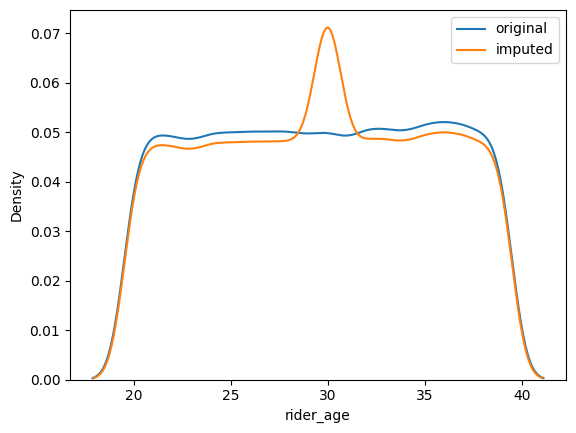

In [46]:
sns.kdeplot(x_train['rider_age'], label='original')
sns.kdeplot(x_train['rider_age'].fillna(age_median), label='imputed')
plt.legend()

- data ka distribution chage ho gya isse to 
- advanced inputation technique use krna chahiye

### ratings

In [47]:
x_train['ratings'].describe()

,ratings
count,34891.000000
mean,4.635058
std,0.314049
min,2.500000
25%,4.500000
50%,4.700000
75%,4.900000
max,5.000000


In [48]:
x_train['ratings'].isna().sum()

np.int64(1510)

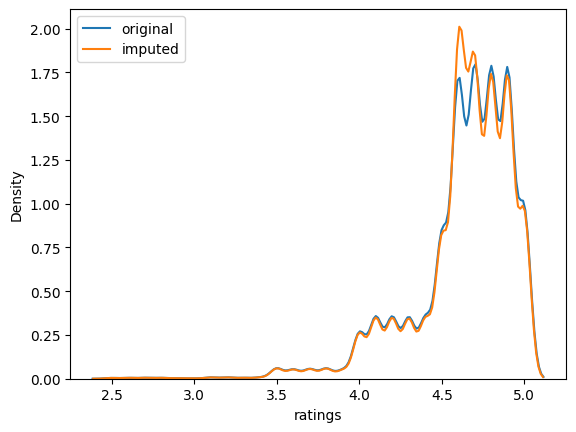

In [49]:
avg_rating = x_train['ratings'].mean()

sns.kdeplot(x_train['ratings'], label='original')
sns.kdeplot(x_train['ratings'].fillna(avg_rating), label='imputed')
plt.legend()

### weather

In [50]:
x_train['weather'].isna().sum()

np.int64(421)

In [51]:
x_train['weather'].value_counts()

,count
weather,
fog,6160
stormy,6051
cloudy,6033
sandstorms,5958
windy,5928
sunny,5850


<Axes: xlabel='weather', ylabel='count'>

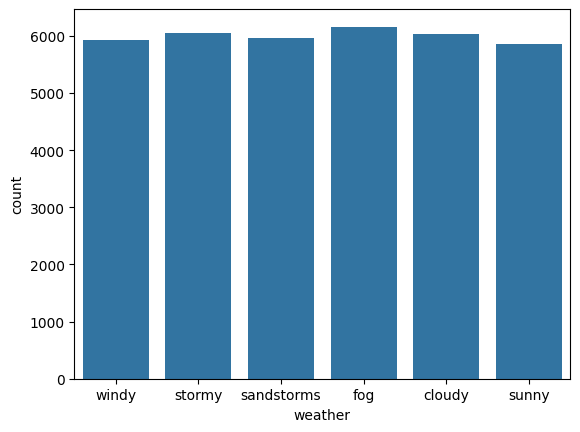

In [52]:
sns.countplot(x=x_train['weather'])

- koi dominent category nhi hai  

In [53]:
missing_weather = MissingIndicator()
missing_weather.set_output(transform='pandas')

pd.concat([x_train['weather'], missing_weather.fit_transform(x_train[['weather']])], axis=1).sample(50)

,weather,missingindicator_weather
17193,stormy,False
14203,windy,False
17481,cloudy,False
8582,sandstorms,False
4493,windy,False
36277,sunny,False
38608,sandstorms,False
26935,sandstorms,False
5580,cloudy,False
8912,windy,False


### traffic

In [54]:
x_train['traffic'].value_counts()

,count
traffic,
low,12323
jam,11320
medium,8773
high,3578


<Axes: xlabel='traffic', ylabel='count'>

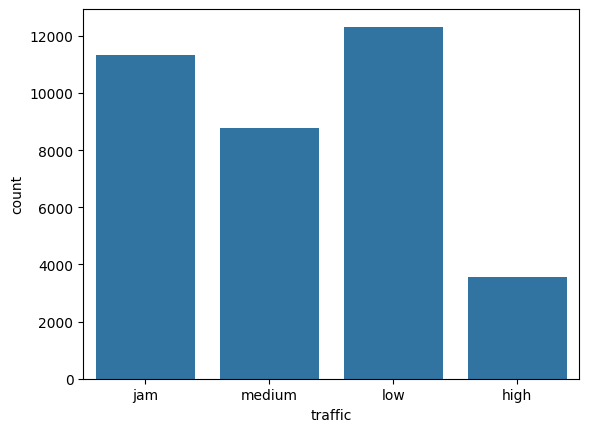

In [55]:
sns.countplot(x=x_train['traffic'])

In [56]:
x_train['traffic'].isna().sum()

np.int64(407)

- no dominent category

### multiple_deliveries

In [57]:
x_train['multiple_deliveries'].value_counts()

,count
multiple_deliveries,
1.0,22487
0.0,11252
2.0,1599
3.0,268


In [58]:
x_train['multiple_deliveries'].isna().sum()

np.int64(795)

<Axes: xlabel='multiple_deliveries', ylabel='count'>

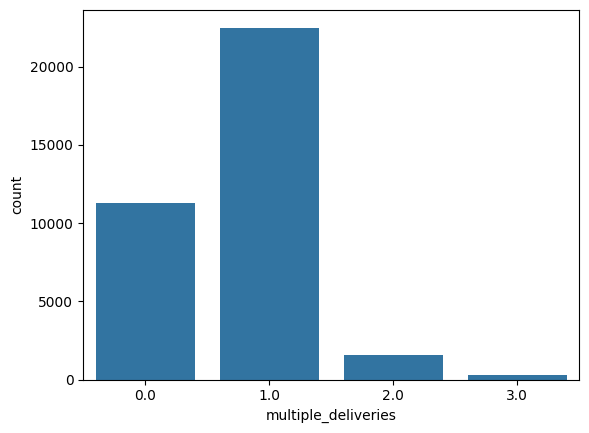

In [59]:
sns.countplot(x=x_train['multiple_deliveries'])

<Axes: xlabel='multiple_deliveries', ylabel='count'>

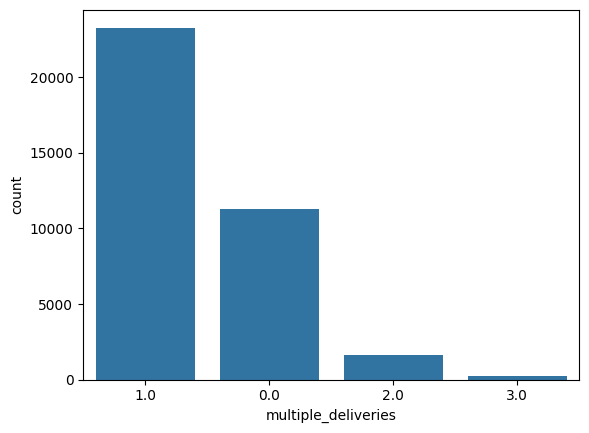

In [60]:
multiple_deliveries_mode = x_train['multiple_deliveries'].mode()[0]

sns.countplot(x=x_train['multiple_deliveries'].fillna(multiple_deliveries_mode).apply(str))

- ye mode se nan fill krna shi dikh ra hai to kr skte hai 

### festival

In [61]:
x_train['festival'].value_counts()

,count
festival,
no,35474
yes,739


<Axes: xlabel='festival', ylabel='count'>

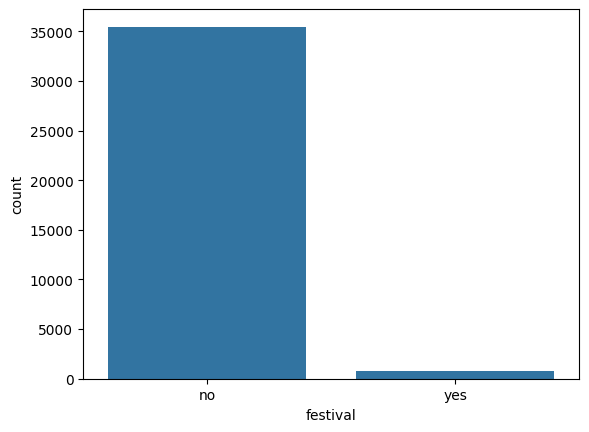

In [62]:
sns.countplot(x=x_train['festival'])

In [63]:
x_train['festival'].isna().sum()

np.int64(188)

<Axes: xlabel='festival', ylabel='count'>

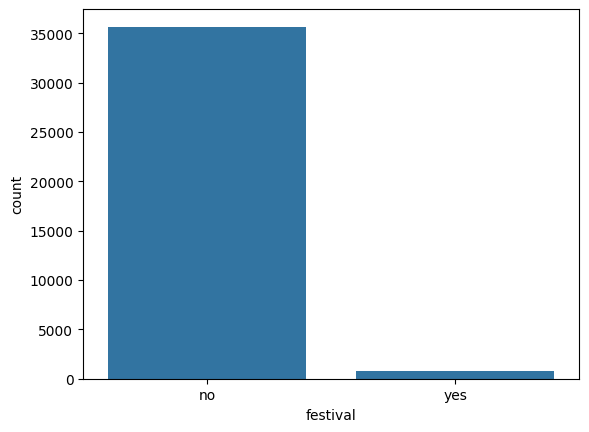

In [64]:
festival_mode = x_train['festival'].mode()[0]

sns.countplot(x=x_train['festival'].fillna(festival_mode))

### city_type

In [65]:
x_train['city_type'].value_counts()

,count
city_type,
metropolitian,27245
urban,8058
semi-urban,130


In [66]:
x_train['city_type'].isna().sum()

np.int64(968)

<Axes: xlabel='city_type', ylabel='count'>

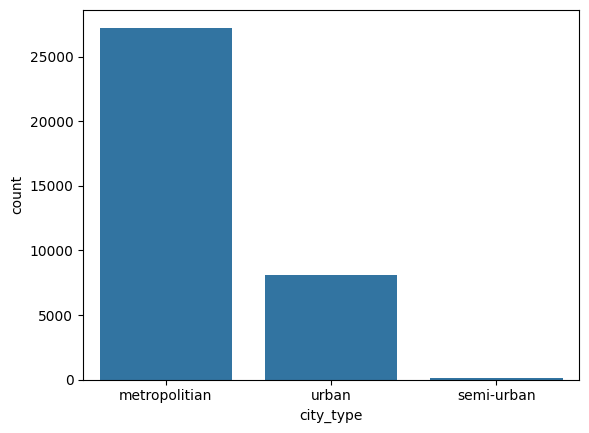

In [67]:
sns.countplot(x=x_train['city_type'])

<Axes: xlabel='city_type', ylabel='count'>

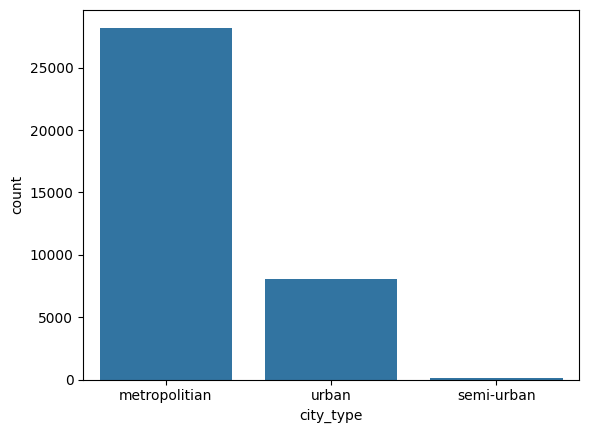

In [68]:
city_type_mode = x_train['city_type'].mode()[0]

sns.countplot(x=x_train['city_type'].fillna(city_type_mode))

### pickup_time_minutes 

In [69]:
x_train['pickup_time_minutes'].isna().sum()

np.int64(1298)

In [70]:
x_train['pickup_time_minutes'].describe()

,pickup_time_minutes
count,35103.000000
mean,9.998718
std,4.082279
min,5.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,15.000000


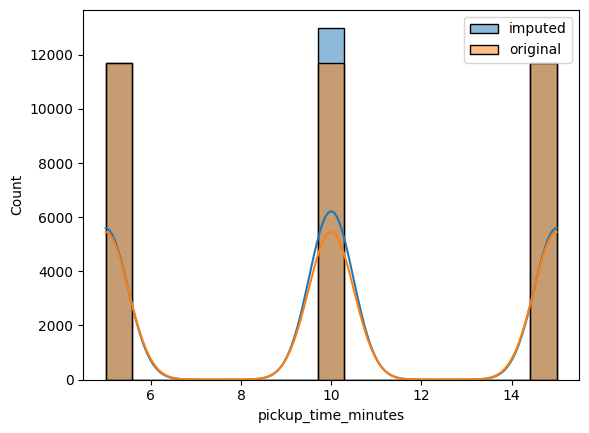

In [71]:
pickup_time_median = x_train['pickup_time_minutes'].median()

sns.histplot(x=x_train['pickup_time_minutes'].fillna(pickup_time_median), kde=True, label='imputed')
sns.histplot(x=x_train['pickup_time_minutes'], kde=True, label='original')
plt.legend()

### Order_time_of_day

In [72]:
x_train['order_time_of_day'].isna().sum()

np.int64(1646)

In [73]:
x_train['order_time_of_day'].value_counts()

,count
order_time_of_day,
night,10994
evening,10906
morning,6883
afternoon,5972


<Axes: xlabel='order_time_of_day', ylabel='count'>

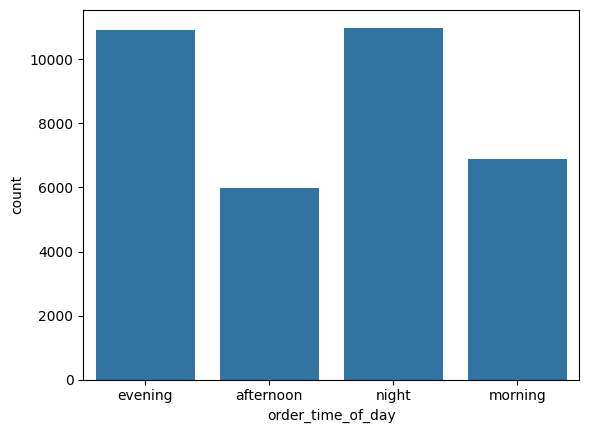

In [74]:
sns.countplot(x=x_train['order_time_of_day'])

In [75]:
x_train[x_train['order_time_of_day'].isna()]

,rider_age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,city_name,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
14475,NaN,NaN,stormy,low,2,meal,scooter,1.0,no,metropolitian,MYS,3,saturday,1,NaN,NaN,1.554563,short
21916,20.0,2.8,sunny,low,2,drinks,scooter,1.0,no,metropolitian,JAP,3,wednesday,0,10.0,NaN,10.427236,long
34951,28.0,5.0,fog,low,2,snack,motorcycle,1.0,no,metropolitian,HYD,3,sunday,1,15.0,NaN,16.903757,very_long
8165,NaN,NaN,NaN,NaN,3,meal,scooter,1.0,no,metropolitian,KOL,2,wednesday,0,NaN,NaN,19.673431,very_long
23469,NaN,NaN,sunny,jam,0,buffet,motorcycle,1.0,no,metropolitian,COIMB,4,tuesday,0,NaN,NaN,4.674220,short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33827,NaN,NaN,NaN,NaN,3,drinks,electric_scooter,1.0,no,urban,GOA,2,monday,0,NaN,NaN,NaN,NaN
22403,NaN,NaN,sunny,low,0,snack,motorcycle,1.0,no,urban,INDO,3,monday,0,NaN,NaN,3.024981,short
21518,NaN,NaN,stormy,jam,1,meal,scooter,0.0,no,urban,MYS,4,saturday,1,NaN,NaN,17.097973,very_long
22002,25.0,5.0,sunny,low,1,meal,scooter,1.0,no,metropolitian,LUDH,2,tuesday,0,5.0,NaN,8.789430,medium


### distance

In [76]:
x_train['distance'].describe()

,distance
count,33470.000000
mean,9.738154
std,5.608401
min,1.465067
25%,4.657672
50%,9.193421
75%,13.681057
max,20.969489


In [77]:
x_train['distance'].isna().sum()

np.int64(2931)

In [78]:
avg_distance = x_train['distance'].mean()

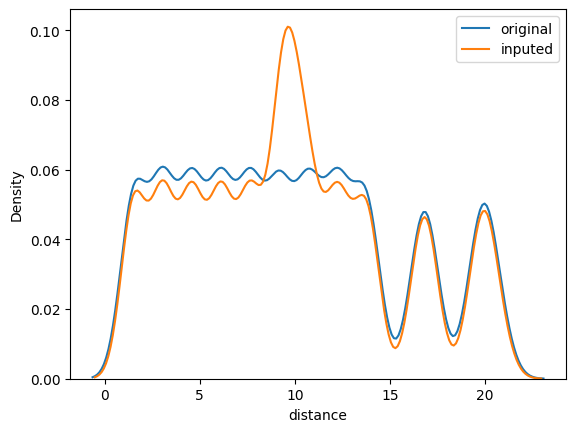

In [79]:
sns.kdeplot(x_train['distance'], label='original')
sns.kdeplot(x_train['distance'].fillna(avg_distance), label='inputed')
plt.legend()

In [80]:
missing_cols

Index(['rider_age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [81]:
x_train['distance_type'].isna().sum()

np.int64(2931)

In [84]:
x_train['distance_type'].value_counts()

,count
distance_type,
long,9025
short,8998
medium,8993
very_long,6454


<Axes: xlabel='distance_type', ylabel='count'>

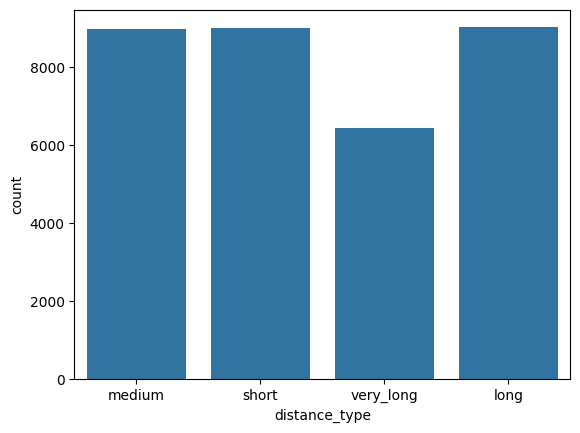

In [86]:
sns.countplot(x=x_train['distance_type'])

- mode use nhi kr skte hai kyuki isme bhi itna jyada difference nhi hai
 

## Imputation pipeline

In [87]:
nominal_cat_cols

['weather',
 'type_of_vehicle',
 'festival',
 'city_type',
 'city_name',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_of_day',
 'type_of_order']

In [88]:
x_train.isna().sum()

,0
rider_age,1470
ratings,1510
weather,421
traffic,407
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,795
festival,188
city_type,968


In [89]:
features_to_fill_mode = ['city_type', 'multiple_deliveries', 'festival']
features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

features_to_fill_missing

['weather',
 'type_of_vehicle',
 'city_name',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_of_day',
 'type_of_order']

In [ ]:
simple_imputer = ColumnTransformer(transformers=[
    ('mode_imputer', SimpleImputer(strategy='most_frequent'), features_to_fill_mode),
    # ye isliye kiya kyuki OHE missing rows pr kam ni krta hai to hmne wha missing dal diya 
    ('missing_imputer', SimpleImputer(strategy='constant', fill_value='missing'), features_to_fill_missing)
], remainder='passthrough', n_jobs=-1, force_int_remainder_cols=False, verbose_feature_names_out=False)

simple_imputer

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('mode_imputer',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['city_type', 'multiple_deliveries',
                                  'festival']),
                                ('missing_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['weather', 'type_of_vehicle', 'city_name',
                                  'order_month', 'order_day_of_week',
                                  'is_weekend', 'order_time_of_day',
                                  'type_of_order'])],
                  verbose_feature_names_out=False)

In [92]:
simple_imputer.fit_transform(x_train)

,city_type,multiple_deliveries,festival,weather,type_of_vehicle,city_name,order_month,order_day_of_week,is_weekend,order_time_of_day,type_of_order,rider_age,ratings,traffic,vehicle_condition,pickup_time_minutes,distance,distance_type
11029,metropolitian,1.0,no,windy,electric_scooter,MUM,3,wednesday,0,evening,snack,26.0,4.7,jam,2,10.0,9.177684,medium
15665,metropolitian,1.0,no,windy,motorcycle,SUR,3,thursday,0,afternoon,drinks,21.0,4.9,medium,2,5.0,6.081536,medium
14475,metropolitian,1.0,no,stormy,scooter,MYS,3,saturday,1,missing,meal,NaN,NaN,low,2,NaN,1.554563,short
29199,metropolitian,1.0,no,windy,motorcycle,JAP,4,monday,0,evening,buffet,32.0,4.7,medium,0,15.0,20.852271,very_long
22514,urban,0.0,no,sandstorms,scooter,RANCHI,3,wednesday,0,night,meal,34.0,4.9,jam,1,5.0,9.056096,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,metropolitian,0.0,no,sandstorms,scooter,COIMB,4,monday,0,evening,meal,29.0,4.7,jam,2,5.0,12.464367,long
44732,urban,0.0,no,cloudy,motorcycle,SUR,3,wednesday,0,morning,buffet,36.0,4.8,low,0,10.0,1.520432,short
38158,metropolitian,0.0,no,fog,scooter,BHP,2,thursday,0,evening,buffet,36.0,4.4,jam,1,10.0,NaN,NaN
860,metropolitian,1.0,no,windy,scooter,CHEN,3,saturday,1,afternoon,meal,25.0,4.9,medium,2,5.0,7.760938,medium


In [93]:
simple_imputer.fit_transform(x_train).isna().sum()

,0
city_type,0
multiple_deliveries,0
festival,0
weather,0
type_of_vehicle,0
city_name,0
order_month,0
order_day_of_week,0
is_weekend,0
order_time_of_day,0


In [94]:
knn_imputer = KNNImputer(n_neighbors=5)

In [109]:
num_cols = ['rider_age', 'ratings', 'pickup_time_minutes', 'distance']

nominal_cat_cols = [
    'weather',
    'type_of_vehicle',
    'festival',
    'city_type',
    'city_name',
    'order_month',
    'order_day_of_week',
    'is_weekend',
    'order_time_of_day',
    'type_of_order'
]

ordinal_cat_cols = ['traffic', 'distance_type']

In [110]:
traffic_order = ['low', 'medium', 'high', 'jam']

distance_type_order = ['short', 'medium', 'long', 'very_long']

In [111]:
for col in ordinal_cat_cols:
    print(col, x_train[col].unique())

traffic ['jam' 'medium' 'low' 'high' nan]
distance_type ['medium' 'short' 'very_long' 'long' nan]


In [112]:
preprocessor = ColumnTransformer(transformers=[
    ('scale', MinMaxScaler(), num_cols),
    ('nominal_encode', OneHotEncoder(drop='first', 
                                     handle_unknown='ignore', 
                                     sparse_output=False), nominal_cat_cols),
    ('ordinal_encode', OrdinalEncoder(categories=[traffic_order, distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown='use_encoded_value',
                                      unknown_value=-1), ordinal_cat_cols)                                                      
], remainder='passthrough', n_jobs=-1, force_int_remainder_cols=False, verbose_feature_names_out=False)

preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['rider_age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_vehicle', 'festival',
                                  'city_type', 'city_name', 'order_month',
                                  'order_day_of_week', 'is_weekend',
                                  'order_time_of_day', 'type_of_order']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [113]:
preprocessor.fit_transform(x_train)

,rider_age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,weather_nan,...,order_time_of_day_morning,order_time_of_day_night,order_time_of_day_nan,type_of_order_drinks,type_of_order_meal,type_of_order_snack,traffic,distance_type,vehicle_condition,multiple_deliveries
11029,0.315789,0.88,0.5,0.395429,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2,1.0
15665,0.052632,0.96,0.0,0.236688,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,2,1.0
14475,NaN,NaN,NaN,0.004588,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2,1.0
29199,0.631579,0.88,1.0,0.993990,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0,1.0
22514,0.736842,0.96,0.0,0.389195,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,3.0,1.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.473684,0.88,0.0,0.563939,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0,2,0.0
44732,0.842105,0.92,0.5,0.002839,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
38158,0.842105,0.76,0.5,NaN,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,-1.0,1,0.0
860,0.263158,0.96,0.0,0.322792,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,2,1.0


In [114]:
preprocessor.fit_transform(x_train).isna().sum().loc[lambda ser: ser.ge(1)]

,0
rider_age,1470
ratings,1510
pickup_time_minutes,1298
distance,2931
multiple_deliveries,795


In [116]:
processing_pipeline = Pipeline(steps=[
    ('simple_imputer', simple_imputer),
    ('preprocess', preprocessor),
    ('knn_imputer', knn_imputer)
])

processing_pipeline

Pipeline(steps=[('simple_imputer',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('mode_imputer',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['city_type',
                                                   'multiple_deliveries',
                                                   'festival']),
                                                 ('missing_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant'),
                                                  ['weather', 'type_of_vehicle',
                                                   'city_name'...
                                                   'order_day_of_week',
                                                   'is_weekend',
                                                   'order_time_of_day',
                                                   'type_of_order']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False)),
                ('knn_imputer', KNNImputer())])

In [117]:
processing_pipeline.fit_transform(x_train)

,rider_age,ratings,pickup_time_minutes,distance,weather_fog,weather_missing,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,...,order_time_of_day_missing,order_time_of_day_morning,order_time_of_day_night,type_of_order_drinks,type_of_order_meal,type_of_order_snack,traffic,distance_type,multiple_deliveries,vehicle_condition
11029,0.315789,0.880,0.5,0.395429,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,1.0,2.0
15665,0.052632,0.960,0.0,0.236688,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,2.0
14475,0.536842,0.896,0.5,0.004588,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0
29199,0.631579,0.880,1.0,0.993990,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,0.0
22514,0.736842,0.960,0.0,0.389195,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,3.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.473684,0.880,0.0,0.563939,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0,0.0,2.0
44732,0.842105,0.920,0.5,0.002839,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38158,0.842105,0.760,0.5,0.189351,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,-1.0,0.0,1.0
860,0.263158,0.960,0.0,0.322792,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0


In [118]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

model_pipe = Pipeline(steps=[
    ('preprocessin', processing_pipeline),
    ('model', lr)
])

model_pipe

Pipeline(steps=[('preprocessin',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['city_type',
                                                                    'multiple_deliveries',
                                                                    'festival']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weathe...
                                                                    'order_time_of_day',
                                                                    'type_of_order']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', LinearRegression())])

In [120]:
model_pipe.fit(x_train, y_train_pt)

Pipeline(steps=[('preprocessin',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['city_type',
                                                                    'multiple_deliveries',
                                                                    'festival']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weathe...
                                                                    'order_time_of_day',
                                                                    'type_of_order']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', LinearRegression())])

In [121]:
y_pred_train = model_pipe.predict(x_train)
y_pred_test = model_pipe.predict(x_test)

In [123]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [124]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f'MAE on train data is {mean_absolute_error(y_train, y_pred_train_org): .2f} minutes')
print(f'MAE on test data is {mean_absolute_error(y_test, y_pred_test_org): .2f} minutest')

MAE on train data is  4.83 minutes
MAE on test data is  4.86 minutest


In [125]:
print(f'r2_score on train data is {r2_score(y_train, y_pred_train_org): .2f}')
print(f'r2_score on test data is {r2_score(y_test, y_pred_test_org): .2f}')

r2_score on train data is  0.58
r2_score on test data is  0.58


In [132]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

model_pipe = Pipeline(steps=[
    ('preprocessing', processing_pipeline),
    ('model', rf)
])

model_pipe

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['city_type',
                                                                    'multiple_deliveries',
                                                                    'festival']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weath...
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [133]:
model_pipe.fit(x_train, y_train_pt.values.ravel())

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['city_type',
                                                                    'multiple_deliveries',
                                                                    'festival']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weath...
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [134]:
y_pred_train = model_pipe.predict(x_train)
y_pred_test = model_pipe.predict(x_test)

In [135]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1, 1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1, 1))

In [136]:
print(f'MAE on train data is {mean_absolute_error(y_train, y_pred_train_org): .2f} minutes')
print(f'MAE on test data is {mean_absolute_error(y_test, y_pred_test_org): .2f} minutest')

MAE on train data is  1.22 minutes
MAE on test data is  3.30 minutest


In [137]:
print(f'r2_score on train data is {r2_score(y_train, y_pred_train_org): .2f}')
print(f'r2_score on test data is {r2_score(y_test, y_pred_test_org): .2f}')

r2_score on train data is  0.97
r2_score on test data is  0.80
